# Benchmark des Modèles Naïfs de Prévision des Ventes

## Objectifs
- Évaluer les modèles naïfs
- Tester sur plusieurs à partir d'une durée d'entraînement de 4 ans
- Analyser les performances sur 2 horizons de prévision (1 à 4 semaines)
- Établir des baselines pour les modèles avancés



Changer 

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error as mae
import os
os.chdir("../")
os.getcwd()

'/home/clfournier/home_dev/store_sales_time_series'

In [2]:
from src.naive_benchmark import NaiveBenchmark

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Chargement des Données

In [3]:
sales_df = pd.read_csv('data/sales_data.csv')

print(f"Dataset: {len(sales_df):,} lignes, {len(sales_df.columns)} colonnes")
print(f"Période: {sales_df['date'].min()} à {sales_df['date'].max()}")
print(f"Magasins: {sales_df['store_nbr'].nunique()}, Familles: {sales_df['family'].nunique()}")

Dataset: 3,000,888 lignes, 56 colonnes
Période: 2013-01-01 à 2017-08-15
Magasins: 54, Familles: 33


In [4]:
sales_df.head()

,Unnamed: 0,id,date,store_nbr,family,sales,onpromotion,day_of_week,month,year,...,is_holiday_regional,is_holiday_national,is_store_closed,rolling_mean_56,log_sales,diff_sales,family_store_nb,family_state,family_onpromotion,is_family_unactive
0,0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,2013,...,0,1,1,NaN,0.000000,NaN,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
1,1,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2,1,2013,...,0,0,0,NaN,1.098612,NaN,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
2,2,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,3,1,2013,...,0,0,0,NaN,1.386294,2.0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
3,3,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,4,1,2013,...,0,0,0,NaN,1.386294,1.0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
4,4,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,5,1,2013,...,0,1,0,NaN,1.791759,0.0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0


## 3. Initialisation du Benchmark

In [5]:
benchmark = NaiveBenchmark(sales_df, compute_missing_features=True)

print(f"Modèles disponibles: {len(benchmark.models)}")
for model_name in benchmark.models.keys():
    print(f"  - {model_name}")

[INFO] Modèles actifs: ['Naive_Simple', 'Naive_Seasonal_Weekly', 'Naive_Seasonal_Yearly', 'Naive_Mean_7d', 'Naive_Mean_30d', 'Naive_Mean_90d', 'Naive_Drift']
Modèles disponibles: 7
  - Naive_Simple
  - Naive_Seasonal_Weekly
  - Naive_Seasonal_Yearly
  - Naive_Mean_7d
  - Naive_Mean_30d
  - Naive_Mean_90d
  - Naive_Drift


## 4. Description des Modèles du Cours

### Modèles implémentés

| Modèle | Formule | Description |
|--------|---------|-------------|
| Naive_Simple | y_T+h = y_T | Dernière valeur observée |
| Naive_Seasonal_Weekly | y_T+h = y_T+h-7 | Même jour de la semaine dernière |
| Naive_Seasonal_Yearly | y_T+h = y_T+h-365 | Même période l'année dernière |
| Naive_Mean_7d | y_T+h = moyenne(y_T, ..., y_T-6) | Moyenne mobile 7 jours |
| Naive_Mean_30d | y_T+h = moyenne(y_T, ..., y_T-29) | Moyenne mobile 30 jours |
| Naive_Mean_90d | y_T+h = moyenne(y_T, ..., y_T-89) | Moyenne mobile 90 jours |
| Naive_Drift | y_T+h = y_T + h×(y_T - y_1)/(T-1) | Avec tendance linéaire |

### Notation
- T : dernier point d'observation (fin du train)
- h : horizon de prévision (en jours)
- y_T+h : prévision pour T+h jours

## 5. Évaluation

Contrairement à une approche globale consistant à calculer les erreurs sur l’ensemble des observations mélangées, notre benchmark évalue les modèles séparément pour chaque couple (store, family).

Logique d'évaluation:
- **4 ans** : Train 2013-01-01 → 2017-01-01, puis test sur les semaines suivantes

Métriques: MAE, RMSLE

In [6]:
all_results = benchmark.evaluate_all_configurations(
    train_years=[4],
    week_horizons=[1,4]  
)

## 6. Tableau Comparatif

In [7]:
comparison_df = benchmark.get_comparison_table(all_results)
comparison_df

,Modèle,Train,Horizon,Jours,MAE,RMSLE
0,Naive_Simple,4a,w+1,7,304.43,2.5396
1,Naive_Simple,4a,w+4,28,175.21,1.3585
2,Naive_Seasonal_Weekly,4a,w+1,7,253.64,1.8967
3,Naive_Seasonal_Weekly,4a,w+4,28,147.91,1.3602
4,Naive_Seasonal_Yearly,4a,w+1,7,128.80,0.6666
5,Naive_Seasonal_Yearly,4a,w+4,28,157.76,0.7298
6,Naive_Mean_7d,4a,w+1,7,225.24,1.8130
7,Naive_Mean_7d,4a,w+4,28,149.11,0.9932
8,Naive_Mean_30d,4a,w+1,7,212.01,1.7890
9,Naive_Mean_30d,4a,w+4,28,162.14,1.0231


## 7. Analyse par Configuration

### 7.1 Performance par horizon (3 ans d'entraînement)

In [8]:
pivot_3y = comparison_df[comparison_df['Train'] == '4a'].pivot(
    index='Modèle', 
    columns='Horizon', 
    values='RMSLE'
)
pivot_3y

Horizon,w+1,w+4
Modèle,,
Naive_Drift,1.9118,1.2225
Naive_Mean_30d,1.7890,1.0231
Naive_Mean_7d,1.8130,0.9932
Naive_Mean_90d,1.7307,0.9748
Naive_Seasonal_Weekly,1.8967,1.3602
Naive_Seasonal_Yearly,0.6666,0.7298
Naive_Simple,2.5396,1.3585


### 7.2 MAE moyen par durée d'entraînement

In [9]:
pivot_train = comparison_df.groupby(['Modèle', 'Train'])['RMSLE'].mean().unstack()
pivot_train

Train,4a
Modèle,
Naive_Drift,1.56715
Naive_Mean_30d,1.40605
Naive_Mean_7d,1.40310
Naive_Mean_90d,1.35275
Naive_Seasonal_Weekly,1.62845
Naive_Seasonal_Yearly,0.69820
Naive_Simple,1.94905


## 8. Visualisations

### 8.1 MAE par horizon de prévision

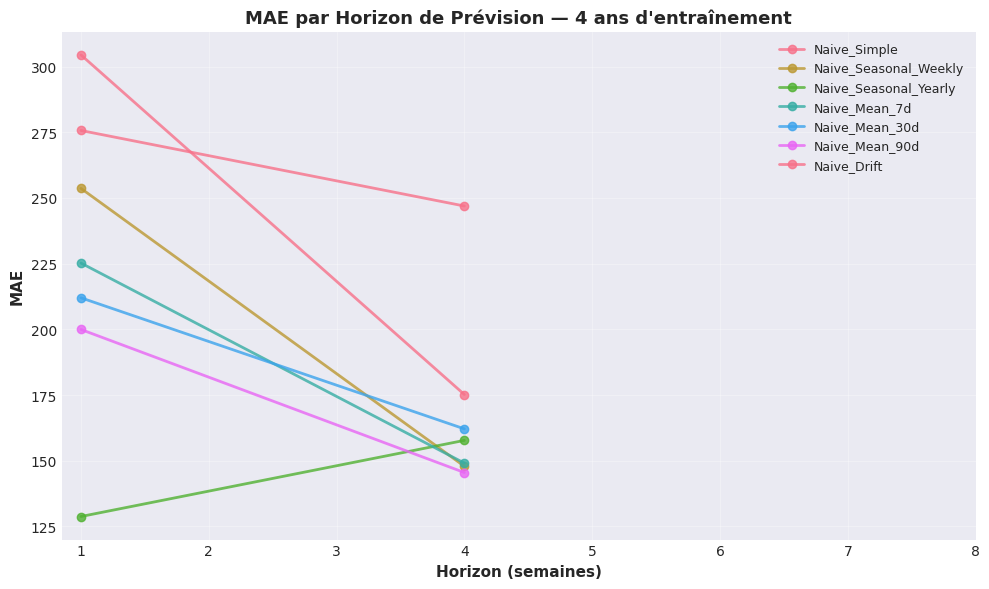

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as mae

n_years = 4

fig, ax = plt.subplots(figsize=(10, 6))

for model_name, model_results in all_results.items():
    mae_by_horizon = []
    horizons = []

    for week_horizon in range(1, 9):
        key = (n_years, week_horizon)
        if key in model_results:
            df_h = model_results[key]
            mae_score = mae(df_h["actual"], df_h["predicted"])
            mae_by_horizon.append(mae_score)
            horizons.append(week_horizon)

    if mae_by_horizon:
        ax.plot(horizons, mae_by_horizon, marker="o", linewidth=2,
                markersize=6, label=model_name, alpha=0.8)

ax.set_xlabel("Horizon (semaines)", fontsize=11, fontweight="bold")
ax.set_ylabel("MAE", fontsize=11, fontweight="bold")
ax.set_title("MAE par Horizon de Prévision — 4 ans d'entraînement", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
ax.set_xticks(list(range(1, 9)))

plt.tight_layout()
plt.show()


## 9. Classement Global

In [12]:
ranking_df = benchmark.get_global_ranking(all_results)
ranking_df

,Modèle,MAE_moyen,RMSLE_moyen
0,Naive_Seasonal_Yearly,143.281629,0.698196
1,Naive_Mean_90d,172.743544,1.352746
2,Naive_Mean_30d,187.079532,1.406050
3,Naive_Mean_7d,187.174728,1.403110
4,Naive_Seasonal_Weekly,200.776721,1.628479
5,Naive_Simple,239.823460,1.949020
6,Naive_Drift,261.306818,1.567182


In [13]:
ranking_df

,Modèle,MAE_moyen,RMSLE_moyen
0,Naive_Seasonal_Yearly,143.281629,0.698196
1,Naive_Mean_90d,172.743544,1.352746
2,Naive_Mean_30d,187.079532,1.406050
3,Naive_Mean_7d,187.174728,1.403110
4,Naive_Seasonal_Weekly,200.776721,1.628479
5,Naive_Simple,239.823460,1.949020
6,Naive_Drift,261.306818,1.567182


In [14]:
best_overall = ranking_df.iloc[0]['Modèle']
best_mae = ranking_df.iloc[0]['MAE_moyen']

print(f"Meilleur modèle global: {best_overall}")
print(f"MAE moyen: {best_mae:.2f}")

Meilleur modèle global: Naive_Seasonal_Yearly
MAE moyen: 143.28
